## Отчет по эксперименту с обучением на сбалансированном датасете

## Цель эксперимента
Оценить влияние балансировки классов на качество моделей бинарной классификации (дефолт заемщика). Цель — проверить, повысит ли балансировка обучающей выборки способность моделей предсказывать миноритарный класс (дефолт), при сохранении реалистичной оценки на естественном распределении классов в валидации и тесте.

## Методология

`Данные`:
Обучающая выборка (`train`): была **сбалансирована** с помощью `SMOTETomek` (комбинация SMOTE и Tomek links). Итоговое распределение: 50% дефолтов, 50% не-дефолтов.
Валидационная (`val`) и тестовая (`test`) выборки: **не балансировались**, распределение классов в них осталось исходным (≈88.4% не-дефолт, ≈11.6% дефолт). Это позволило оценить работу моделей в условиях реального дисбаланса.

`Модели`:
Логистическая регрессия
Дерево решений
Случайный лес
XGBoost
LightGBM
MLP (нейронная сеть)

**Метрики**: Accuracy, F1-score, Precision, Recall, ROC-AUC (для вероятностных моделей). Основной фокус — на `Recall` и `F1` для класса "дефолт", так как false negative здесь критичнее.

## Результаты на валидационной выборке

| Модель | Accuracy | F1 (дефолт) | Recall (дефолт) | Precision (дефолт) | ROC-AUC |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **LogReg** | 0.885 | 0.075 | 0.040 | 0.577 | 0.749 |
| **DecisionTree** | 0.881 | 0.034 | 0.018 | 0.309 | 0.675 |
| **RandomForest** | 0.884 | 0.022 | 0.011 | 0.628 | 0.744 |
| **XGBoost** | 0.887 | 0.152 | 0.087 | 0.581 | 0.747 |
| **LightGBM** | 0.887 | 0.145 | 0.082 | 0.599 | 0.754 |
| **MLP** | 0.887 | 0.092 | 0.050 | 0.658 | 0.756 |

## Анализ результатов

**Главное наблюдение: эксперимент не дал прироста качества и привел к тому, что модели практически перестали видеть класс 1.**

*   **Низкий Recall для класса 1**: Значения Recall (доля правильно предсказанных дефолтов) для всех моделей крайне низки (от **1% до 8%**). Это означает, что модели пропускают подавляющее большинство реальных дефолтов на несбалансированной валидации. Балансировка `train` **не помогла** моделям обобщиться на реальный дисбаланс.

## Сохранённые артефакты

| Тип | Путь |
|-----|------|
| Метрики моделей | `../artifacts/ExperimentBalanced/runsExp.csv` |
| Матрицы ошибок | `../artifacts/ExperimentBalanced/figures` |
| ROC-кривые | `../artifacts/ExperimentBalanced/figures` |
| PR-кривые | `../artifacts/ExperimentBalanced/figures` |
| Конфиги моделей | `../configs/experimentBalanced_config.json` |

In [2]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from scipy.stats import uniform, loguniform, randint


from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.combine import SMOTETomek

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)

In [ ]:
df = pd.read_csv("../data/PROCESSED/LoanDefaultPredictionDatasetPROC.csv")


X = df.drop("Default", axis=1)
y = df["Default"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

smk = SMOTETomek(random_state=42)
X_train, y_train = smk.fit_resample(X_train, y_train) #балансируем классы для обучающей выборки, оставляя оригинальные данные в val и test выборках для реалистичной оценки модели

print("Размеры выборок:")
print("train:", X_train.shape)
print("val:", X_val.shape)
print("test:", X_test.shape)

print("\nРаспределение классов (train):")
print(y_train.value_counts(normalize=True))
print("\nРаспределение классов (val):")
print(y_val.value_counts(normalize=True))
print("\nРаспределение классов (test):")
print(y_test.value_counts(normalize=True))


In [ ]:
expLogReg = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "logreg",
            LogisticRegression(
                penalty="l2",
                C=1.0,         
                solver="saga", 
                random_state=42,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-4,
            ),
        ),
    ]
)

# Настроим сетку по параметру C (сила регуляризации)
param_grid = {
    # Сила регуляризации
    "logreg__C": loguniform(0.01, 100),
    
    # Тип регуляризации (L1, L2, ElasticNet)
    "logreg__penalty": ["l1", "l2", "elasticnet"],
    
    # Соотношение L1/L2 для elasticnet (только при penalty='elasticnet')
    "logreg__l1_ratio": uniform(0, 1),
        
    # Порог сходимости
    "logreg__tol": loguniform(1e-5, 1e-3),
    
    # Максимальное число итераций (можно увеличить для сходимости при малых C)
    "logreg__max_iter": randint(1000, 5001),
    
    # Веса классов (разные стратегии)
    "logreg__class_weight": ["balanced", None],
    
    # Использовать ли intercept
    "logreg__fit_intercept": [True, False],
}

random_search = RandomizedSearchCV(
    estimator=expLogReg,
    param_distributions=param_grid,
    n_iter=500,
    scoring="f1",    # можно поменять на f1, recall и т.д.
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)

print("Лучшие параметры:", random_search.best_params_)
print("Лучший F1 (по CV):", random_search.best_score_)

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
Лучшие параметры: {'logreg__C': 0.13431925993528135, 'logreg__class_weight': None, 'logreg__fit_intercept': True, 'logreg__l1_ratio': 0.7506147516408583, 'logreg__max_iter': 3239, 'logreg__penalty': 'elasticnet', 'logreg__tol': 0.0009572167377160833}
Лучший F1 (по CV): 0.9272674628199095


In [ ]:
expDecisionTree = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

param_distributions_tree = {
    # Максимальная глубина дерева
    "max_depth": randint(3, 30),
    
    # Минимальное количество для разбиения узла
    "min_samples_split": randint(20, 200),
    
    # Минимальное количество в листе
    "min_samples_leaf": randint(10, 100),
    
    # Критерий качества разбиения
    "criterion": ["gini", "entropy", "log_loss"],
    
    # Максимальное количество признаков для поиска лучшего разбиения
    "max_features": ["sqrt", "log2", None, 0.3, 0.5, 0.7],
    
    # Минимальное взвешенное количество в листе
    "min_weight_fraction_leaf": uniform(0, 0.05),
    
    # Минимальное уменьшение примеси для разбиения
    "min_impurity_decrease": [0.0, 1e-7, 1e-6, 1e-5, 1e-4],
    
    # Параметр для обрезки (cost complexity pruning)
    "ccp_alpha": [0.0, 0.0001, 0.001, 0.005, 0.01, 0.05],
    
    # Стратегия разбиения
    "splitter": ["best", "random"],
}
random_search_tree = RandomizedSearchCV(
    estimator=expDecisionTree,
    param_distributions=param_distributions_tree,
    n_iter=500,  # количество комбинаций
    scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    return_train_score=True,
    verbose=2
)
random_search_tree.fit(X_train, y_train)

print("Лучшие параметры:", random_search_tree.best_params_)
print("Лучший F1 (по CV):", random_search_tree.best_score_)

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
[CV] END ccp_alpha=0.005, criterion=gini, max_depth=17, max_features=None, min_impurity_decrease=0.0001, min_samples_leaf=30, min_samples_split=122, min_weight_fraction_leaf=0.02229163764267956, splitter=best; total time=   1.1s
[CV] END ccp_alpha=0.005, criterion=gini, max_depth=17, max_features=None, min_impurity_decrease=0.0001, min_samples_leaf=30, min_samples_split=122, min_weight_fraction_leaf=0.02229163764267956, splitter=best; total time=   1.1s
[CV] END ccp_alpha=0.005, criterion=gini, max_depth=17, max_features=None, min_impurity_decrease=0.0001, min_samples_leaf=30, min_samples_split=122, min_weight_fraction_leaf=0.02229163764267956, splitter=best; total time=   1.1s
[CV] END ccp_alpha=0.005, criterion=gini, max_depth=17, max_features=None, min_impurity_decrease=0.0001, min_samples_leaf=30, min_samples_split=122, min_weight_fraction_leaf=0.02229163764267956, splitter=best; total time=   1.1s
[CV] END ccp_alpha=0

In [ ]:
randomForest = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
)

param_distributions_rf = {
    # Количество деревьев
    "n_estimators": randint(100, 300),
    
    # Максимальная глубина
    "max_depth": [15, 30, None],
    
    # Минимальное количество для разбиения
    "min_samples_split": randint(10, 200),
    
    # Минимальное количество в листе
    "min_samples_leaf": randint(5, 100),
    
    # Количество признаков для поиска лучшего разбиения
    "max_features": ["sqrt", "log2", None, 0.3, 0.5, 0.7],
    
    # Критерий качества
    "criterion": ["gini", "entropy"],
    
    # Bootstrap (нужно ли)
    "bootstrap": [True, False],
}

random_search_rf = RandomizedSearchCV(
    estimator=randomForest,
    param_distributions=param_distributions_rf,
    n_iter=30,  # 30 комбинаций
    scoring="f1",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),  
    random_state=42, 
    verbose=2,
    return_train_score=True
)

random_search_rf.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END bootstrap=True, criterion=entropy, max_depth=15, max_features=None, min_samples_leaf=76, min_samples_split=198, n_estimators=120; total time= 2.2min
[CV] END bootstrap=True, criterion=entropy, max_depth=15, max_features=None, min_samples_leaf=76, min_samples_split=198, n_estimators=120; total time= 2.5min
[CV] END bootstrap=True, criterion=entropy, max_depth=15, max_features=None, min_samples_leaf=76, min_samples_split=198, n_estimators=120; total time= 2.2min
[CV] END bootstrap=True, criterion=entropy, max_depth=None, max_features=None, min_samples_leaf=79, min_samples_split=97, n_estimators=216; total time= 4.2min
[CV] END bootstrap=True, criterion=entropy, max_depth=None, max_features=None, min_samples_leaf=79, min_samples_split=97, n_estimators=216; total time= 4.0min
[CV] END bootstrap=True, criterion=entropy, max_depth=None, max_features=None, min_samples_leaf=79, min_samples_split=97, n_estimators=216; total t

RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=42),
                   n_iter=30,
                   param_distributions={'bootstrap': [True, False],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [15, 30, None],
                                        'max_features': ['sqrt', 'log2', None,
                                                         0.3, 0.5, 0.7],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000017038C3CA50>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000017038C3F810>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000017066906C50>},
                   random_state=42, return_train_score=True, scoring='f1',
                   verbose=2)

In [ ]:
def compute_metrics(y_true, y_pred, y_proba=None):
    methrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred)),
        "Precision": float(precision_score(y_val, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_val, y_pred, zero_division=0)),
    }
    if y_proba is None:
        methrics["roc_auc"] = None
    else:
        try:
            methrics["roc_auc"] = float(roc_auc_score(y_true, y_proba))
        except Exception:
            methrics["roc_auc"] = None
    return methrics

def evaluate_on_test(model, X_test, y_test, label):
    pred = model.predict(X_test)
    proba = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    methrics = compute_metrics(y_test, pred, proba)
    methrics["model"] = label
    return methrics

runsExp = []

runsExp.append(evaluate_on_test(random_search.best_estimator_, X_val, y_val, "LogRegBalanced"))
runsExp.append(evaluate_on_test(random_search_tree.best_estimator_, X_val, y_val, "DecisionTreeBalanced"))
runsExp.append(evaluate_on_test(random_search_rf.best_estimator_, X_val, y_val, "RandomForestBalanced"))


for i in runsExp:
    print(i)


{'accuracy': 0.8851234922458358, 'f1': 0.07524169819251786, 'Precision': 0.5774193548387097, 'Recall': 0.04024280575539568, 'roc_auc': 0.7485250818368169, 'model': 'LogRegBalanced'}
{'accuracy': 0.881285572554958, 'f1': 0.033991926917357126, 'Precision': 0.3088803088803089, 'Recall': 0.017985611510791366, 'roc_auc': 0.6748062252773547, 'model': 'DecisionTreeBalanced'}
{'accuracy': 0.8843924599237638, 'f1': 0.021652673442333188, 'Precision': 0.6282051282051282, 'Recall': 0.011016187050359711, 'roc_auc': 0.7435297036193931, 'model': 'RandomForestBalanced'}


In [ ]:
print("LogReg", classification_report(y_val,  random_search.best_estimator_.predict(X_val), target_names=["Не дефолт", "Дефолт"]), sep='\n')
print("DecisionTree", classification_report(y_val,  random_search_tree.best_estimator_.predict(X_val), target_names=["Не дефолт", "Дефолт"]), sep='\n')
print("RandomForest", classification_report(y_val,  random_search_rf.best_estimator_.predict(X_val), target_names=["Не дефолт", "Дефолт"]), sep='\n')

LogReg
              precision    recall  f1-score   support

   Не дефолт       0.89      1.00      0.94     33854
      Дефолт       0.58      0.04      0.08      4448

    accuracy                           0.89     38302
   macro avg       0.73      0.52      0.51     38302
weighted avg       0.85      0.89      0.84     38302

DecisionTree
              precision    recall  f1-score   support

   Не дефолт       0.89      0.99      0.94     33854
      Дефолт       0.31      0.02      0.03      4448

    accuracy                           0.88     38302
   macro avg       0.60      0.51      0.49     38302
weighted avg       0.82      0.88      0.83     38302

RandomForest
              precision    recall  f1-score   support

   Не дефолт       0.88      1.00      0.94     33854
      Дефолт       0.63      0.01      0.02      4448

    accuracy                           0.88     38302
   macro avg       0.76      0.51      0.48     38302
weighted avg       0.86      0.88      0.

In [ ]:
import xgboost as xgb
import lightgbm as lgb

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

# Параметры для поиска
param_distributions_xgb = {
    # Количество деревьев
    'n_estimators': randint(100, 500),
    
    # Максимальная глубина
    'max_depth': randint(3, 12),
    
    # Learning rate
    'learning_rate': uniform(0.01, 0.3),
    
    # Субдискретизация по строкам
    'subsample': uniform(0.6, 0.4),
    
    # Субдискретизация по колонкам
    'colsample_bytree': uniform(0.6, 0.4),
    'colsample_bylevel': uniform(0.6, 0.4),
    'colsample_bynode': uniform(0.6, 0.4),
    
    # Регуляризация
    'reg_alpha': uniform(0, 2),    # L1
    'reg_lambda': uniform(0, 2),   # L2
    
    # Минимальный вес в листе (борьба с дисбалансом)
    'min_child_weight': randint(1, 10),
    
    # Тип бустинга
    'booster': ['gbtree', 'dart'],
    
    # Параметры для dart
    'sample_type': ['uniform', 'weighted'],
    'normalize_type': ['tree', 'forest'],
    'rate_drop': uniform(0, 0.5),
    'skip_drop': uniform(0, 0.5),
}

# Случайный поиск
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions_xgb,
    n_iter=30,
    scoring='f1',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=1,
    random_state=42,
    verbose=2,
    return_train_score=True
)


random_search_xgb.fit(X_train, y_train)

print("Лучшие параметры XGBoost:")
print(random_search_xgb.best_params_)
print(f"Лучший F1: {random_search_xgb.best_score_:.4f}")

# Результаты на валидации
best_xgb = random_search_xgb.best_estimator_


Fitting 3 folds for each of 30 candidates, totalling 90 fits


d:\study\aie_std\AIEngineering_CoursMIREA\project\.venv\Lib\site-packages\xgboost\core.py:160: UserWarning: [18:18:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "normalize_type", "rate_drop", "sample_type", "skip_drop" } are not used.

  warnings.warn(smsg, UserWarning)


[CV] END booster=gbtree, colsample_bylevel=0.9186171947440931, colsample_bynode=0.6733739159464655, colsample_bytree=0.9118764001091078, learning_rate=0.1890550473839461, max_depth=5, min_child_weight=7, n_estimators=430, normalize_type=tree, rate_drop=0.4330880728874676, reg_alpha=1.2022300234864176, reg_lambda=1.416145155592091, sample_type=weighted, skip_drop=0.028205789513550128, subsample=0.8887995089067299; total time=   1.2s


d:\study\aie_std\AIEngineering_CoursMIREA\project\.venv\Lib\site-packages\xgboost\core.py:160: UserWarning: [18:18:35] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "normalize_type", "rate_drop", "sample_type", "skip_drop" } are not used.

  warnings.warn(smsg, UserWarning)


[CV] END booster=gbtree, colsample_bylevel=0.9186171947440931, colsample_bynode=0.6733739159464655, colsample_bytree=0.9118764001091078, learning_rate=0.1890550473839461, max_depth=5, min_child_weight=7, n_estimators=430, normalize_type=tree, rate_drop=0.4330880728874676, reg_alpha=1.2022300234864176, reg_lambda=1.416145155592091, sample_type=weighted, skip_drop=0.028205789513550128, subsample=0.8887995089067299; total time=   1.2s


...

[CV] END booster=gbtree, colsample_bylevel=0.7346216859554906, colsample_bynode=0.8622890541522968, colsample_bytree=0.754158648386226, learning_rate=0.21448410069183693, max_depth=4, min_child_weight=3, n_estimators=204, normalize_type=tree, rate_drop=0.05908241381082813, reg_alpha=1.3934743307283013, reg_lambda=1.257885693559768, sample_type=uniform, skip_drop=0.019593163337823127, subsample=0.7671784126862315; total time=   0.6s


d:\study\aie_std\AIEngineering_CoursMIREA\project\.venv\Lib\site-packages\xgboost\core.py:160: UserWarning: [21:26:25] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "normalize_type", "rate_drop", "sample_type", "skip_drop" } are not used.

  warnings.warn(smsg, UserWarning)


[CV] END booster=gbtree, colsample_bylevel=0.7346216859554906, colsample_bynode=0.8622890541522968, colsample_bytree=0.754158648386226, learning_rate=0.21448410069183693, max_depth=4, min_child_weight=3, n_estimators=204, normalize_type=tree, rate_drop=0.05908241381082813, reg_alpha=1.3934743307283013, reg_lambda=1.257885693559768, sample_type=uniform, skip_drop=0.019593163337823127, subsample=0.7671784126862315; total time=   0.5s


d:\study\aie_std\AIEngineering_CoursMIREA\project\.venv\Lib\site-packages\xgboost\core.py:160: UserWarning: [21:26:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "normalize_type", "rate_drop", "sample_type", "skip_drop" } are not used.

  warnings.warn(smsg, UserWarning)


Лучшие параметры XGBoost:
{'booster': 'gbtree', 'colsample_bylevel': 0.9376852562905246, 'colsample_bynode': 0.9720067339243328, 'colsample_bytree': 0.6281664523398175, 'learning_rate': 0.07267561528460804, 'max_depth': 8, 'min_child_weight': 7, 'n_estimators': 226, 'normalize_type': 'tree', 'rate_drop': 0.14764529420946937, 'reg_alpha': 0.645101528477201, 'reg_lambda': 1.6973395898493489, 'sample_type': 'uniform', 'skip_drop': 0.35124204199355463, 'subsample': 0.743796460487902}
Лучший F1: 0.9285


In [ ]:
# Базовая модель
lgb_model = lgb.LGBMClassifier(
    random_state=42,
    verbose=-1,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

# Параметры для поиска
param_distributions_lgb = {
    # Количество деревьев
    'n_estimators': randint(100, 1000),
    
    # Максимальная глубина
    'max_depth': randint(3, 15),
    'num_leaves': randint(10, 150),  # LightGBM специфичный параметр
    
    # Learning rate
    'learning_rate': uniform(0.01, 0.3),
    
    # Субдискретизация
    'subsample': uniform(0.6, 0.4),
    'subsample_freq': randint(1, 10),
    
    # Субдискретизация по колонкам
    'colsample_bytree': uniform(0.6, 0.4),
    
    # Регуляризация
    'reg_alpha': uniform(0, 2),
    'reg_lambda': uniform(0, 2),
    
    # Минимальное количество данных в листе
    'min_child_samples': randint(5, 50),
    'min_child_weight': uniform(0, 0.1),
    
    # Тип бустинга
    'boosting_type': ['gbdt', 'dart', 'goss'],
    
}

random_search_lgb = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_distributions_lgb,
    n_iter=100,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=1,
    random_state=42,
    verbose=2,
    return_train_score=True
)

random_search_lgb.fit(X_train, y_train)

print("Лучшие параметры LightGBM:")
print(random_search_lgb.best_params_)
print(f"Лучший F1: {random_search_lgb.best_score_:.4f}")

# Результаты на валидации
best_lgb = random_search_lgb.best_estimator_


Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END boosting_type=goss, colsample_bytree=0.9186171947440931, learning_rate=0.06503043695984914, max_depth=10, min_child_samples=25, min_child_weight=0.015601864044243652, n_estimators=566, num_leaves=84, reg_alpha=0.9184977839317343, reg_lambda=0.6674172222780437, subsample=0.6571467271687763, subsample_freq=3; total time=   0.1s
[CV] END boosting_type=goss, colsample_bytree=0.9186171947440931, learning_rate=0.06503043695984914, max_depth=10, min_child_samples=25, min_child_weight=0.015601864044243652, n_estimators=566, num_leaves=84, reg_alpha=0.9184977839317343, reg_lambda=0.6674172222780437, subsample=0.6571467271687763, subsample_freq=3; total time=   0.1s
[CV] END boosting_type=goss, colsample_bytree=0.9186171947440931, learning_rate=0.06503043695984914, max_depth=10, min_child_samples=25, min_child_weight=0.015601864044243652, n_estimators=566, num_leaves=84, reg_alpha=0.9184977839317343, reg_lambda=0.66741722227

d:\study\aie_std\AIEngineering_CoursMIREA\project\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
180 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
180 fits failed with the following error:
Traceback (most recent call last):
  File "d:\study\aie_std\AIEngineering_CoursMIREA\project\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\study\aie_std\AIEngineering_CoursMIREA\project\.venv\Lib\site-packages\lightgbm\sklearn.py", line 1142, in fit
    super().fit(
  File "d:\study\aie_std\AIEngineering_CoursMIREA\project\.venv\Lib\site-packages\lightgbm\sklearn.py", li

Лучшие параметры LightGBM:
{'boosting_type': 'gbdt', 'colsample_bytree': 0.6769156075234684, 'learning_rate': 0.02226058487994366, 'max_depth': 7, 'min_child_samples': 22, 'min_child_weight': 0.027859033903195864, 'n_estimators': 928, 'num_leaves': 31, 'reg_alpha': 0.17740506751411123, 'reg_lambda': 0.24127174220120162, 'subsample': 0.7843115072130903, 'subsample_freq': 2}
Лучший F1: 0.9287


In [ ]:
runsExp.append(evaluate_on_test(best_xgb, X_val, y_val, "XgbBalanced"))
runsExp.append(evaluate_on_test(best_lgb, X_val, y_val, "LgbBalanced"))

for i in runsExp:
    print(i)


{'accuracy': 0.8851234922458358, 'f1': 0.07524169819251786, 'Precision': 0.5774193548387097, 'Recall': 0.04024280575539568, 'roc_auc': 0.7485250818368169, 'model': 'LogRegBalanced'}
{'accuracy': 0.881285572554958, 'f1': 0.033991926917357126, 'Precision': 0.3088803088803089, 'Recall': 0.017985611510791366, 'roc_auc': 0.6748062252773547, 'model': 'DecisionTreeBalanced'}
{'accuracy': 0.8843924599237638, 'f1': 0.021652673442333188, 'Precision': 0.6282051282051282, 'Recall': 0.011016187050359711, 'roc_auc': 0.7435297036193931, 'model': 'RandomForestBalanced'}
{'accuracy': 0.8866899900788471, 'f1': 0.15201250488472057, 'Precision': 0.5805970149253732, 'Recall': 0.08745503597122302, 'roc_auc': 0.7468090767092123, 'model': 'XgbBalanced'}
{'accuracy': 0.8870293979426662, 'f1': 0.1446926270013837, 'Precision': 0.5990180032733224, 'Recall': 0.0822841726618705, 'roc_auc': 0.7541103024710851, 'model': 'LgbBalanced'}


In [ ]:
print("XGB", classification_report(y_val,  random_search.best_estimator_.predict(X_val), target_names=["Не дефолт", "Дефолт"]), sep='\n')
print("LGB", classification_report(y_val,  random_search_tree.best_estimator_.predict(X_val), target_names=["Не дефолт", "Дефолт"]), sep='\n')


XGB
              precision    recall  f1-score   support

   Не дефолт       0.89      1.00      0.94     33854
      Дефолт       0.58      0.04      0.08      4448

    accuracy                           0.89     38302
   macro avg       0.73      0.52      0.51     38302
weighted avg       0.85      0.89      0.84     38302

LGB
              precision    recall  f1-score   support

   Не дефолт       0.89      0.99      0.94     33854
      Дефолт       0.31      0.02      0.03      4448

    accuracy                           0.88     38302
   macro avg       0.60      0.51      0.49     38302
weighted avg       0.82      0.88      0.83     38302



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import random
from sklearn.utils.class_weight import compute_class_weight

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("torch:", torch.__version__)
print("cuda:", torch.version.cuda)
print(f"device: {device}")

torch: 2.1.2+cu118
cuda: 11.8
device: cuda


In [ ]:
def f_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    preds = preds.view(-1)   
    y_true = y_true.view(-1)
    tp = ((preds == 1) & (y_true == 1)).sum().float()
    fp = ((preds == 1) & (y_true == 0)).sum().float()
    fn = ((preds == 0) & (y_true == 1)).sum().float()
    
    # Считаем precision и recall
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    
    # Считаем F1
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
    
    return f1.item()

def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_f": [...],  "val_f": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.savefig("../artifacts/ExperimentBalanced/figures/loss_hist.png")
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_f"], label="train_f")
    plt.plot(epochs, history["val_f"], label="val_f")
    plt.xlabel("epoch")
    plt.ylabel("Fscore")
    plt.title((title + " (Fscore)") if title else "Fscore")
    plt.legend()
    plt.grid(True)
    plt.savefig("../artifacts/ExperimentBalanced/figures/f_hist.png")
    plt.show()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_f = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logists = model(x)
        loss = criterion(logists, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        total_f += f_from_logits(logists, y)
        n_batches += 1

    return total_loss / n_batches, total_f / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device): 
    model.eval()
    total_loss = 0.0
    total_f = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logists = model(x)
        loss = criterion(logists, y)

        total_loss += loss.item()
        total_f += f_from_logits(logists, y)
        n_batches += 1

    return total_loss / n_batches, total_f / n_batches

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False
        
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        
        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs=20, early_stopping=None, verbose=True):
    history = {"train_loss": [], "val_loss": [], "train_f": [],  "val_f": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_f = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_f = evaluate(model, val_loader, criterion, device)

        history["train_f"].append(tr_f)
        history["train_loss"].append(tr_loss)
        history["val_f"].append(val_f)
        history["val_loss"].append(val_loss)

        if verbose:
            print(
                    f"epoch {epoch:02d}/{epochs} | "
                    f"train loss={tr_loss:.4f}, f={tr_f:.4f} | "
                    f"val loss={val_loss:.4f}, f={val_f:.4f}"
                )
        
        if early_stopping is not None:
            if early_stopping.step(val_f, model):
                if verbose:
                    print(f"Остановка на эпохе {epoch};\nСворачиваем всю порнографиб, лучший результат: val_f={early_stopping.best_score}")
                early_stopping.restore_best(model)
                break

    return history

class DataFrameDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, target_column, feature_columns=None, transform=None):
        self.dataframe = dataframe
        self.target_column = target_column
        
        if feature_columns is None:
            self.feature_columns = [col for col in dataframe.columns if col != target_column]
        else:
            self.feature_columns = feature_columns
        
        self.transform = transform
        self.X = dataframe[self.feature_columns].values.astype(np.float32)
        self.y = dataframe[target_column].values.astype(np.int64)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        
        # Применяем трансформации (например, нормализацию)
        if self.transform:
            x = self.transform(x)
        
        # Преобразуем в тензоры
        x = torch.from_numpy(x)
        y = torch.tensor(y, dtype=torch.long)
        
        return x, y
    
    def forFit(self):
        return self.X
    
    def setTrans(self, trans):
        self.transform = trans
    
class StandardScalerTransform:
    def __init__(self, scaler=None):
        self.scaler = scaler or StandardScaler()
    
    def fit(self, X):  # X - numpy array
        self.scaler.fit(X)
        return self
    
    def __call__(self, x):  # x - numpy array
        return self.scaler.transform(x.reshape(1, -1)).flatten()

In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df["Default"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["Default"])

train_df = pd.DataFrame(X_train, columns=X_train.columns)
train_df["Default"] = y_train

scaler = StandardScaler()
scaler.fit(train_df.drop("Default", axis=1).values.astype(np.float32))

transformer = StandardScalerTransform(scaler)

train_ds = DataFrameDataset(train_df, "Default", transform=transformer)
val_ds = DataFrameDataset(val_df, "Default", transform=transformer)
test_ds = DataFrameDataset(test_df, "Default", transform=transformer)

print(f"train size: {len(train_ds)}")
print(f"train size: {len(val_ds)}")
print(f"test size: {len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=512, num_workers=0, shuffle=True, pin_memory="False")
val_loader = DataLoader(val_ds, batch_size=512, num_workers=0, shuffle=False, pin_memory="False")
test_loader = DataLoader(test_ds, batch_size=512, num_workers=0, shuffle=False, pin_memory="False")

x_batch, y_batch = next(iter(train_loader))
print(f"x_batch: {x_batch.shape}, {x_batch.dtype}")
print(f"y_batch: {y_batch.shape}, {y_batch.dtype}")

train size: 291446
train size: 38302
test size: 38303
x_batch: torch.Size([512, 31]), torch.float32
y_batch: torch.Size([512]), torch.int64


epoch 01/30 | train loss=0.2456, f=0.9050 | val loss=0.3239, f=0.0000
epoch 02/30 | train loss=0.1973, f=0.9229 | val loss=0.3172, f=0.0000
epoch 03/30 | train loss=0.1928, f=0.9236 | val loss=0.3175, f=0.0000
epoch 04/30 | train loss=0.1915, f=0.9238 | val loss=0.3149, f=0.0000
epoch 05/30 | train loss=0.1906, f=0.9240 | val loss=0.3152, f=0.0000
epoch 06/30 | train loss=0.1893, f=0.9245 | val loss=0.3136, f=0.0000
epoch 07/30 | train loss=0.1896, f=0.9246 | val loss=0.3138, f=0.0000
epoch 08/30 | train loss=0.1896, f=0.9245 | val loss=0.3151, f=0.0075
epoch 09/30 | train loss=0.1879, f=0.9250 | val loss=0.3145, f=0.0000
epoch 10/30 | train loss=0.1880, f=0.9255 | val loss=0.3141, f=0.0000
epoch 11/30 | train loss=0.1874, f=0.9254 | val loss=0.3152, f=0.0000
epoch 12/30 | train loss=0.1877, f=0.9252 | val loss=0.3138, f=0.0000
epoch 13/30 | train loss=0.1885, f=0.9252 | val loss=0.3139, f=0.0738
epoch 14/30 | train loss=0.1871, f=0.9256 | val loss=0.3124, f=0.0914
epoch 15/30 | train 

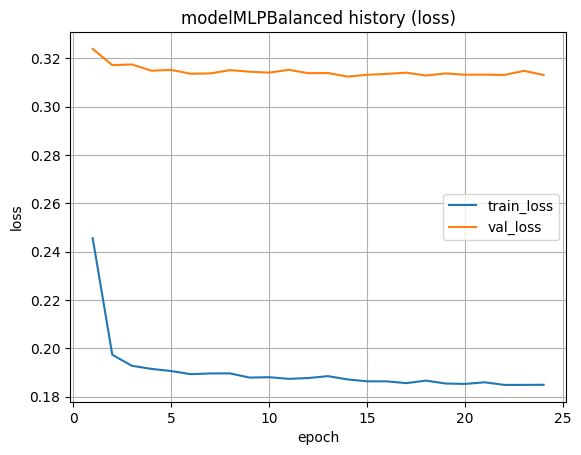

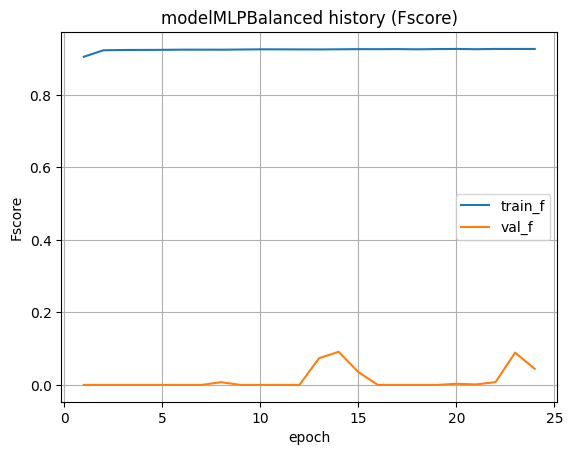

In [ ]:
class MLP(nn.Module):
    def __init__(
            self, 
            input_dim=31,
            hidden_dims=(1024, 512, 1024, 512, 256, 512, 256, 128, 256, 128, 64, 128, 64, 32, 64, 32),
            num_classes=2,
            activation="relu",
            dropout_p=0.25,
            use_batchnorm=True):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)
    
modelMLPBalanced = MLP().to(device)

classes = np.unique(train_df["Default"])
class_weights = compute_class_weight('balanced', classes=classes, y=train_df["Default"])
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(modelMLPBalanced.parameters(), lr=1e-3)

history = fit(modelMLPBalanced, train_loader, val_loader, optimizer, criterion, device, epochs=30, early_stopping=EarlyStopping(10))

plot_history(history, "modelMLPBalanced history")

In [ ]:
def compute_metrics(y_true, y_pred, y_proba=None):
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
    }
    
    if y_proba is not None:
        try:
            metrics["roc_auc"] = float(roc_auc_score(y_true, y_proba))
        except Exception:
            metrics["roc_auc"] = None
    else:
        metrics["roc_auc"] = None
    
    return metrics


def evaluate_on_test_mlp(model, test_loader, device, label="MLP"):
    model.eval()
    all_preds = []
    all_probas = []
    all_labels = []
    
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            
            # Предсказания классов
            preds = torch.argmax(logits, dim=1)
            
            # Вероятности (для ROC-AUC)
            probs = torch.softmax(logits, dim=1)[:, 1]
            
            all_preds.extend(preds.cpu().numpy())
            all_probas.extend(probs.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    metrics = compute_metrics(all_labels, all_preds, all_probas)
    metrics["model"] = label
    
    return metrics

runsExp.append(evaluate_on_test_mlp(modelMLPBalanced, val_loader, device))


In [ ]:
for i in runsExp:
    print(i)

{'accuracy': 0.8851234922458358, 'f1': 0.07524169819251786, 'Precision': 0.5774193548387097, 'Recall': 0.04024280575539568, 'roc_auc': 0.7485250818368169, 'model': 'LogRegBalanced'}
{'accuracy': 0.881285572554958, 'f1': 0.033991926917357126, 'Precision': 0.3088803088803089, 'Recall': 0.017985611510791366, 'roc_auc': 0.6748062252773547, 'model': 'DecisionTreeBalanced'}
{'accuracy': 0.8843924599237638, 'f1': 0.021652673442333188, 'Precision': 0.6282051282051282, 'Recall': 0.011016187050359711, 'roc_auc': 0.7435297036193931, 'model': 'RandomForestBalanced'}
{'accuracy': 0.8866899900788471, 'f1': 0.15201250488472057, 'Precision': 0.5805970149253732, 'Recall': 0.08745503597122302, 'roc_auc': 0.7468090767092123, 'model': 'XgbBalanced'}
{'accuracy': 0.8870293979426662, 'f1': 0.1446926270013837, 'Precision': 0.5990180032733224, 'Recall': 0.0822841726618705, 'roc_auc': 0.7541103024710851, 'model': 'LgbBalanced'}
{'accuracy': 0.8866377734844133, 'f1': 0.0923913043478261, 'precision': 0.657738095

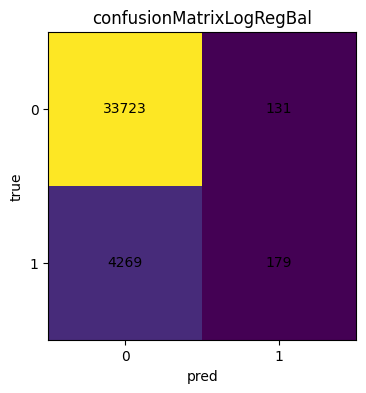

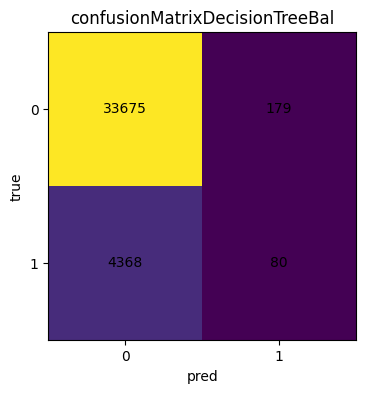

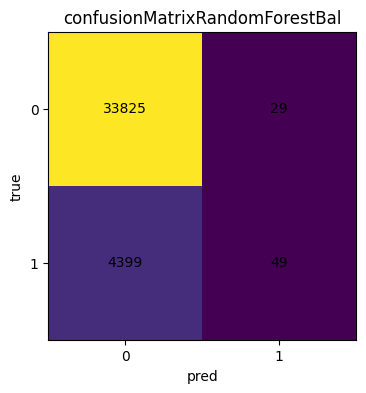

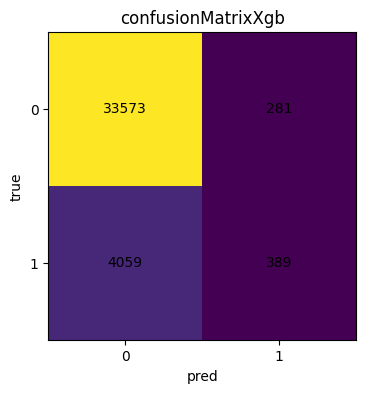

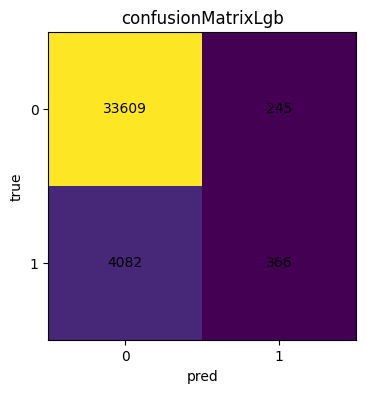

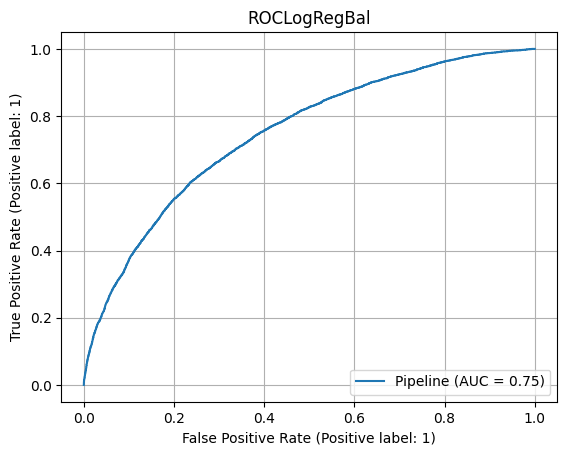

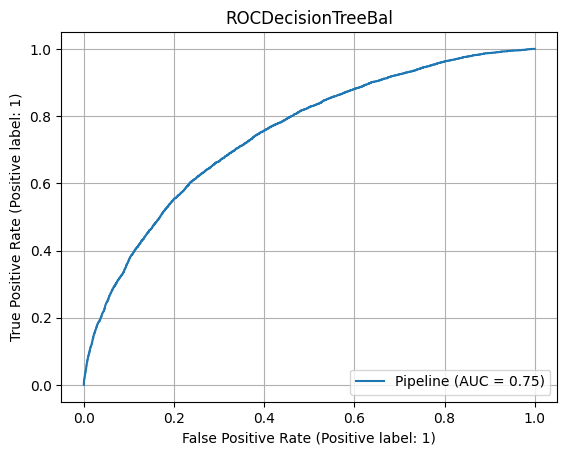

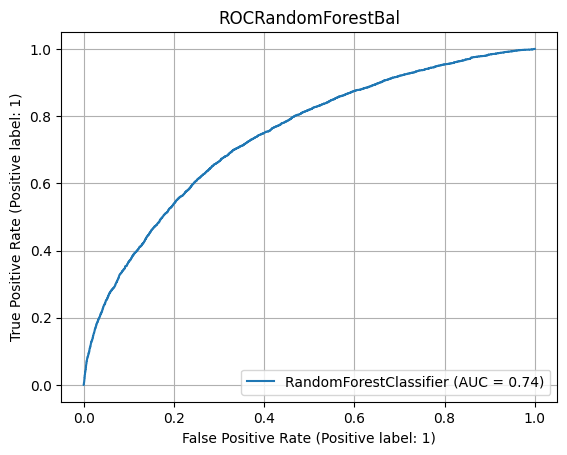

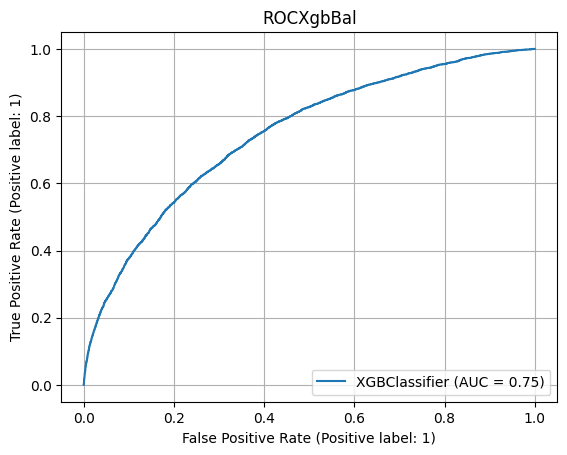

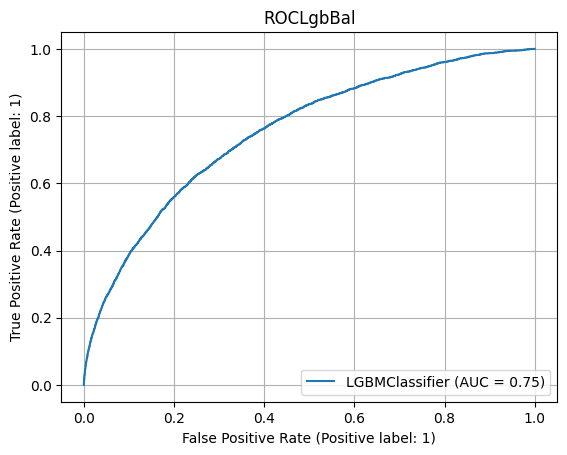

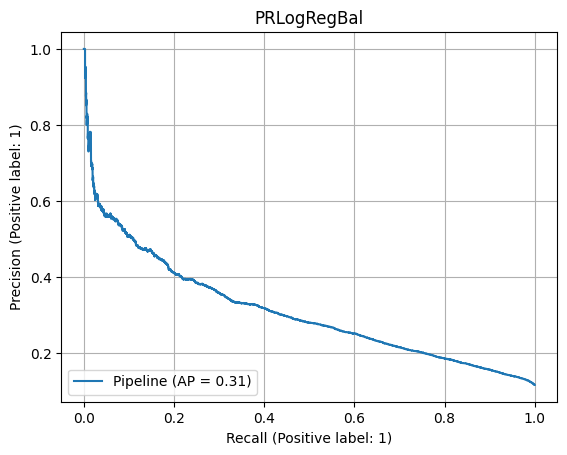

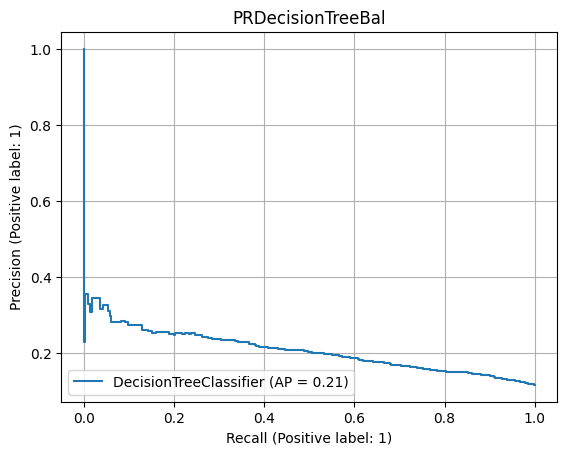

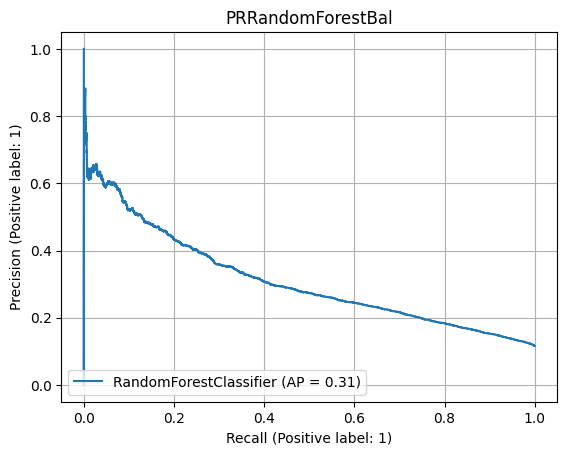

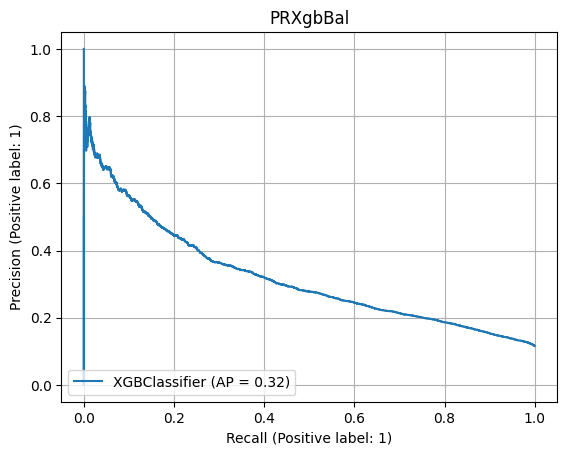

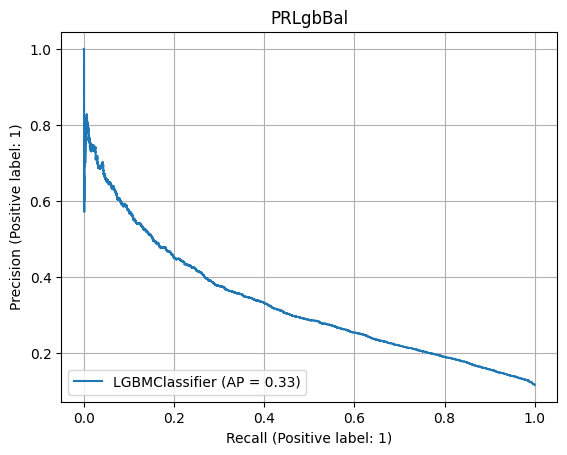

In [ ]:
#рисует матрицу ошибок
def plot_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("pred")
    plt.ylabel("true")
    plt.xticks([0, 1])
    plt.yticks([0, 1])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    pth = f"../artifacts/ExperimentBalanced/figures/{title}.png"
    plt.savefig(pth)
    plt.show()

#рисует roc кривую
def plot_roc(model, X_test, y_test, title: str):
    if not hasattr(model, "predict_proba"):
        print("ROC: модель не поддерживает predict_proba")
        return
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(title)
    plt.grid(True)
    pth = f"../artifacts/ExperimentBalanced/figures/{title}.png"
    plt.savefig(pth)
    plt.show()

def plot_prd(model, X_test, y_test, title):
    if not hasattr(model, "predict_proba"):
        print("PrecisionRecallDisplay: модель не поддерживает predict_proba")
        return
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
    plt.title(title)
    plt.grid(True)
    pth = f"../artifacts/ExperimentBalanced/figures/{title}.png"
    plt.savefig(pth)
    plt.show()

plot_confusion(y_val, random_search.best_estimator_.predict(X_val), "confusionMatrixLogRegBal")
plot_confusion(y_val, random_search_tree.best_estimator_.predict(X_val), "confusionMatrixDecisionTreeBal")
plot_confusion(y_val, random_search_rf.best_estimator_.predict(X_val), "confusionMatrixRandomForestBal")
plot_confusion(y_val, best_xgb.predict(X_val), "confusionMatrixXgb")
plot_confusion(y_val, best_lgb.predict(X_val), "confusionMatrixLgb")


plot_roc(random_search.best_estimator_, X_val, y_val, "ROCLogRegBal")
plot_roc(random_search.best_estimator_, X_val, y_val, "ROCDecisionTreeBal")
plot_roc(random_search_rf.best_estimator_, X_val, y_val, "ROCRandomForestBal")
plot_roc(best_xgb, X_val, y_val, "ROCXgbBal")
plot_roc(best_lgb, X_val, y_val, "ROCLgbBal")

plot_prd(random_search.best_estimator_, X_val, y_val, "PRLogRegBal")
plot_prd(random_search_tree.best_estimator_, X_val, y_val, "PRDecisionTreeBal")
plot_prd(random_search_rf.best_estimator_, X_val, y_val, "PRRandomForestBal")
plot_prd(best_xgb, X_val, y_val, "PRXgbBal")
plot_prd(best_lgb, X_val, y_val, "PRLgbBal")


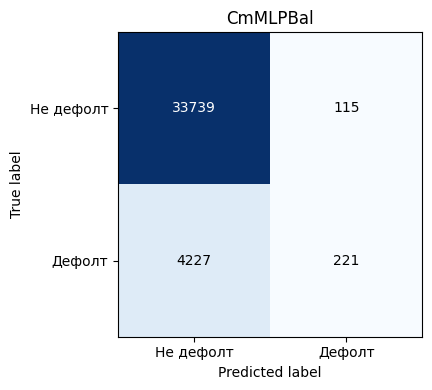

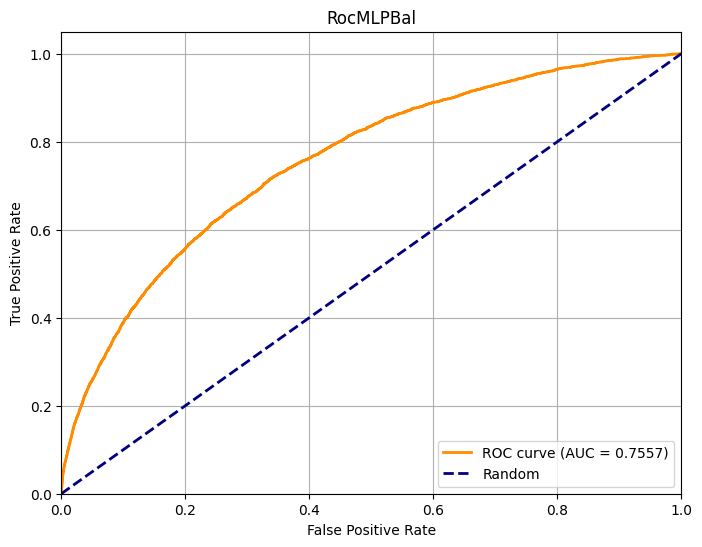

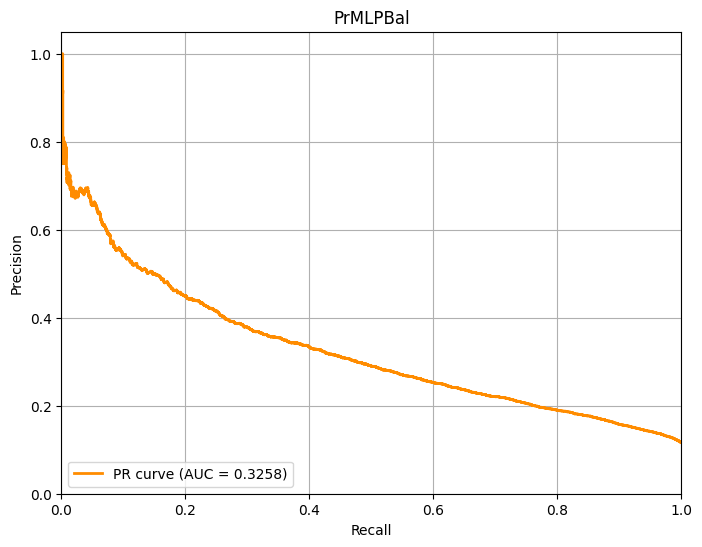

In [ ]:
#рисует матрицу ошибок
def plot_confusion(model, dataloader, device, title: str):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks([0, 1], ['Не дефолт', 'Дефолт'])
    plt.yticks([0, 1], ['Не дефолт', 'Дефолт'])
    
    # Добавляем значения в ячейки
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    
    plt.tight_layout()
    pth = f"../artifacts/ExperimentBalanced/figures/{title}.png"
    plt.savefig(pth)
    plt.show()

#рисует roc кривую
def plot_roc(model, dataloader, device, title: str):
    model.eval()
    all_probas = []
    all_labels = []
    
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[:, 1]  # вероятность класса 1 (дефолт)
            all_probas.extend(probs.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    # Вычисляем ROC
    fpr, tpr, _ = roc_curve(all_labels, all_probas)
    roc_auc = auc(fpr, tpr)
    
    # Рисуем
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True)
    
    pth = f"../artifacts/ExperimentBalanced/figures/{title}.png"
    plt.savefig(pth)
    plt.show()

def plot_prd(model, dataloader, device, title: str):
    model.eval()
    all_probas = []
    all_labels = []
    
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probas.extend(probs.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    # Вычисляем Precision-Recall
    precision, recall, _ = precision_recall_curve(all_labels, all_probas)
    pr_auc = auc(recall, precision)
    
    # Рисуем
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(title)
    plt.legend(loc="lower left")
    plt.grid(True)
    
    pth = f"../artifacts/ExperimentBalanced/figures/{title}.png"
    plt.savefig(pth)
    plt.show()

plot_confusion(modelMLPBalanced, val_loader, device, "CmMLPBal")

plot_roc(modelMLPBalanced, val_loader, device, "RocMLPBal")

plot_prd(modelMLPBalanced, val_loader, device, "PrMLPBal")

In [ ]:
def save_metrics_to_csv(metrics_list, filepath):
    # Создаём DataFrame из списка
    df_metrics = pd.DataFrame(metrics_list)
    
    # Сортируем по ROC-AUC (опционально)
    df_metrics = df_metrics.sort_values('f1', ascending=False)
        
    # Сохраняем в CSV
    df_metrics.to_csv(filepath, index=False)
    print("ГОТОВО!")

save_metrics_to_csv(runsExp, "../artifacts/ExperimentBalanced/runsBalanced.csv")

ГОТОВО!


In [3]:
EXPERIMENT_CONFIG = {
    "data_path": "../data/PROCESSED/LoanDefaultPredictionDatasetPROC.csv",
    "target_column": "Default",
    "random_state": 42,
    "test_size": 0.3,
    "val_size": 0.5,  
    "stratify": True,
    "balance_train": True,
    "balance_method": "SMOTETomek"
}

# Конфигурация Logistic Regression (сбалансированная, найденная)
LOGREG_BALANCED_CONFIG = {
    "model_name": "LogRegBalanced",
    "is_pipeline": True,
    "scaler": {
        "name": "StandardScaler",
        "params": {
            "copy": True,
            "with_mean": True,
            "with_std": True
        }
    },
    "logreg": {
        "penalty": "elasticnet",
        "C": 0.13431925993528135,
        "solver": "saga",
        "random_state": 42,
        "class_weight": None,
        "max_iter": 3239,
        "tol": 0.0009572167377160833,
        "fit_intercept": True,
        "l1_ratio": 0.7506147516408583
    }
}

# Конфигурация Decision Tree (сбалансированная, найденная)
DECISION_TREE_BALANCED_CONFIG = {
    "model_name": "DecisionTreeBalanced",
    "is_pipeline": False,
    "params": {
        "random_state": 42,
        "class_weight": "balanced",
        "ccp_alpha": 0.0001,
        "criterion": "entropy",
        "max_depth": 24,
        "max_features": None,
        "min_impurity_decrease": 0.0001,
        "min_samples_leaf": 50,
        "min_samples_split": 180,
        "min_weight_fraction_leaf": 0.0009037681807760434,
        "splitter": "random"
    }
}

# Конфигурация Random Forest (сбалансированная, найденная)
RANDOM_FOREST_BALANCED_CONFIG = {
    "model_name": "RandomForestBalanced",
    "is_pipeline": False,
    "params": {
        "random_state": 42,
        "class_weight": "balanced",
        "bootstrap": False,
        "criterion": "gini",
        "max_depth": 30,
        "max_features": "sqrt",
        "min_samples_leaf": 10,
        "min_samples_split": 37,
        "n_estimators": 127
    }
}

# Конфигурация XGBoost (сбалансированная, найденная)
XGB_BALANCED_CONFIG = {
    "model_name": "XgbBalanced",
    "is_pipeline": False,
    "params": {
        "random_state": 42,
        "use_label_encoder": False,
        "eval_metric": "logloss",
        "n_jobs": -1,
        "scale_pos_weight": None,  # будет вычислено динамически
        "booster": "gbtree",
        "colsample_bylevel": 0.9376852562905246,
        "colsample_bynode": 0.9720067339243328,
        "colsample_bytree": 0.6281664523398175,
        "learning_rate": 0.07267561528460804,
        "max_depth": 8,
        "min_child_weight": 7,
        "n_estimators": 226,
        "normalize_type": "tree",
        "rate_drop": 0.14764529420946937,
        "reg_alpha": 0.645101528477201,
        "reg_lambda": 1.6973395898493489,
        "sample_type": "uniform",
        "skip_drop": 0.35124204199355463,
        "subsample": 0.743796460487902
    }
}

# Конфигурация LightGBM (сбалансированная, найденная)
LGB_BALANCED_CONFIG = {
    "model_name": "LgbBalanced",
    "is_pipeline": False,
    "params": {
        "random_state": 42,
        "verbose": -1,
        "n_jobs": -1,
        "scale_pos_weight": None,  # будет вычислено динамически
        "boosting_type": "gbdt",
        "colsample_bytree": 0.6769156075234684,
        "learning_rate": 0.02226058487994366,
        "max_depth": 7,
        "min_child_samples": 22,
        "min_child_weight": 0.027859033903195864,
        "n_estimators": 928,
        "num_leaves": 31,
        "reg_alpha": 0.17740506751411123,
        "reg_lambda": 0.24127174220120162,
        "subsample": 0.7843115072130903,
        "subsample_freq": 2
    }
}

# Конфигурация MLP (нейронная сеть, сбалансированная)
MLP_BALANCED_CONFIG = {
    "model_name": "MLP",
    "is_pipeline": False,
    "params": {
        "input_dim": 31,
        "hidden_dims": (1024, 512, 1024, 512, 256, 512, 256, 128, 256, 128, 64, 128, 64, 32, 64, 32),
        "num_classes": 2,
        "activation": "relu",
        "dropout_p": 0.25,
        "use_batchnorm": True,
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "epochs": 30,
        "batch_size": 512,
        "early_stopping_patience": 10,
        "clip_grad_norm": 1.0
    }
}

# Параметры для Random Search (использовались для поиска)
RANDOM_SEARCH_PARAMS = {
    "logreg": {
        "n_iter": 500,
        "cv": 5,
        "scoring": "f1",
        "param_distributions": {
            "logreg__C": "loguniform(0.01, 100)",
            "logreg__penalty": ["l1", "l2", "elasticnet"],
            "logreg__l1_ratio": "uniform(0, 1)",
            "logreg__tol": "loguniform(1e-5, 1e-3)",
            "logreg__max_iter": "randint(1000, 5001)",
            "logreg__class_weight": ["balanced", None],
            "logreg__fit_intercept": [True, False]
        }
    },
    "decision_tree": {
        "n_iter": 500,
        "cv": 5,
        "scoring": "f1",
        "param_distributions": {
            "max_depth": "randint(3, 30)",
            "min_samples_split": "randint(20, 200)",
            "min_samples_leaf": "randint(10, 100)",
            "criterion": ["gini", "entropy", "log_loss"],
            "max_features": ["sqrt", "log2", None, 0.3, 0.5, 0.7],
            "min_weight_fraction_leaf": "uniform(0, 0.05)",
            "min_impurity_decrease": [0.0, 1e-7, 1e-6, 1e-5, 1e-4],
            "ccp_alpha": [0.0, 0.0001, 0.001, 0.005, 0.01, 0.05],
            "splitter": ["best", "random"]
        }
    },
    "random_forest": {
        "n_iter": 30,
        "cv": 3,
        "scoring": "f1",
        "param_distributions": {
            "n_estimators": "randint(100, 300)",
            "max_depth": [15, 30, None],
            "min_samples_split": "randint(10, 200)",
            "min_samples_leaf": "randint(5, 100)",
            "max_features": ["sqrt", "log2", None, 0.3, 0.5, 0.7],
            "criterion": ["gini", "entropy"],
            "bootstrap": [True, False]
        }
    },
    "xgboost": {
        "n_iter": 30,
        "cv": 3,
        "scoring": "f1",
        "param_distributions": {
            "n_estimators": "randint(100, 500)",
            "max_depth": "randint(3, 12)",
            "learning_rate": "uniform(0.01, 0.3)",
            "subsample": "uniform(0.6, 0.4)",
            "colsample_bytree": "uniform(0.6, 0.4)",
            "colsample_bylevel": "uniform(0.6, 0.4)",
            "colsample_bynode": "uniform(0.6, 0.4)",
            "reg_alpha": "uniform(0, 2)",
            "reg_lambda": "uniform(0, 2)",
            "min_child_weight": "randint(1, 10)",
            "booster": ["gbtree", "dart"],
            "sample_type": ["uniform", "weighted"],
            "normalize_type": ["tree", "forest"],
            "rate_drop": "uniform(0, 0.5)",
            "skip_drop": "uniform(0, 0.5)"
        }
    },
    "lightgbm": {
        "n_iter": 100,
        "cv": 5,
        "scoring": "f1",
        "param_distributions": {
            "n_estimators": "randint(100, 1000)",
            "max_depth": "randint(3, 15)",
            "num_leaves": "randint(10, 150)",
            "learning_rate": "uniform(0.01, 0.3)",
            "subsample": "uniform(0.6, 0.4)",
            "subsample_freq": "randint(1, 10)",
            "colsample_bytree": "uniform(0.6, 0.4)",
            "reg_alpha": "uniform(0, 2)",
            "reg_lambda": "uniform(0, 2)",
            "min_child_samples": "randint(5, 50)",
            "min_child_weight": "uniform(0, 0.1)",
            "boosting_type": ["gbdt", "dart", "goss"]
        }
    }
}

# Сводный словарь со всеми конфигурациями экспериментов
ALL_EXPERIMENTS_CONFIG = {
    "experiment": EXPERIMENT_CONFIG,
    "random_search_params": RANDOM_SEARCH_PARAMS,
    "models": {
        "logreg_balanced": LOGREG_BALANCED_CONFIG,
        "decision_tree_balanced": DECISION_TREE_BALANCED_CONFIG,
        "random_forest_balanced": RANDOM_FOREST_BALANCED_CONFIG,
        "xgboost_balanced": XGB_BALANCED_CONFIG,
        "lightgbm_balanced": LGB_BALANCED_CONFIG,
        "mlp_balanced": MLP_BALANCED_CONFIG
    },
    "artifacts": {
        "metrics_path": "../artifacts/ExperimentBalanced/runsBalanced.csv",
        "figures_dir": "../artifacts/ExperimentBalanced/figures",
        "config_path": "../configs/experimentBalanced_config.json"
    }
}

# Сохраняем общий конфиг
with open("../configs/experimentBalanced_config.json", "w") as f:
    json.dump(ALL_EXPERIMENTS_CONFIG, f, indent=4)
    